# 03 — Détection des Anomalies et Fuites — version corrigée
**Projet PFE : Système Intelligent de Gestion de l'Eau — Grand Agadir**

### Corrections appliquées
1. **Seuil optimisé pour le F1** (et plus seulement `contamination`/percentile) — l'AUC montrait déjà
   un bon classement ; on choisit le seuil qui maximise réellement le F1.
2. **Autoencoder entraîné sur les données NORMALES uniquement** — sinon il apprend à reconstruire
   les anomalies et ne les détecte plus.
3. Évaluation : Précision / Rappel / F1 / AUC-ROC + matrice de confusion + analyse fuites vs anomalies.

> Ici, utiliser `flowratelpm`/`pressurebar` comme features est **correct** : une fuite se manifeste
> dans ces signaux **au même instant** (ce n'est pas de la prévision).

## 0. Imports & Configuration

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (precision_recall_fscore_support, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)

DATA_DIR=Path('../data'); MODEL_DIR=Path('../models'); FIG_DIR=Path('../reports/figures')
MODEL_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
LABEL_COL='anomalylabel'
COLORS={'normal':'#2ECC71','anomaly':'#E74C3C','if':'#4E79A7','lstm_ae':'#9B59B6','sigma3':'#59A14F'}
print('✅ Imports OK')

✅ Imports OK


## 1. Chargement & features (communes aux 3 modèles)

In [2]:
t=pd.read_csv(DATA_DIR/'train.csv', parse_dates=['timestamp'])
v=pd.read_csv(DATA_DIR/'test.csv',  parse_dates=['timestamp'])
df=pd.concat([t,v], ignore_index=True)
df.columns=df.columns.str.strip().str.lower()
df=df.sort_values(['meterid','timestamp']).reset_index(drop=True)

for L in [1,24]:
    df[f'lag_{L}']=df.groupby('meterid')['consumptionliters'].shift(L)
df['roll_mean_24']=df.groupby('meterid')['consumptionliters'].transform(lambda x:x.shift(1).rolling(24,min_periods=1).mean())
df['roll_std_24'] =df.groupby('meterid')['consumptionliters'].transform(lambda x:x.shift(1).rolling(24,min_periods=1).std())
df['deviation_ratio']=np.where(df['roll_mean_24']>0,(df['consumptionliters']-df['roll_mean_24'])/df['roll_mean_24'],0)

FEAT=[c for c in ['consumptionliters','flowratelpm','pressurebar','temperaturec',
                  'lag_1','lag_24','roll_mean_24','roll_std_24','deviation_ratio'] if c in df.columns]
df=df.dropna(subset=FEAT).reset_index(drop=True)
y_true=(df[LABEL_COL]!='normal').astype(int).values
print(f'Shape : {df.shape} | features : {FEAT}')
print('Labels :', df[LABEL_COL].value_counts(normalize=True).round(3).to_dict())

def best_f1_threshold(y, score):
    """Retourne le seuil qui maximise le F1 (le classement vient de l'AUC)."""
    p,r,thr=precision_recall_curve(y, score)
    f1=2*p*r/(p+r+1e-9); i=int(np.nanargmax(f1))
    t=thr[min(i,len(thr)-1)]
    pr,rc,f,_=precision_recall_fscore_support(y,(score>=t).astype(int),average='binary',zero_division=0)
    return t,pr,rc,f
results_detection=[]

Shape : (277344, 24) | features : ['consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'lag_1', 'lag_24', 'roll_mean_24', 'roll_std_24', 'deviation_ratio']
Labels : {'normal': 0.96, 'anomaly': 0.025, 'leak': 0.015}


## 2. Modèle 1 — Isolation Forest (seuil F1-optimal)

AUC = 0.897
  défaut (contamination) : P=0.404 R=0.404 F1=0.404
  seuil F1-optimal       : P=0.411 R=0.399 F1=0.405


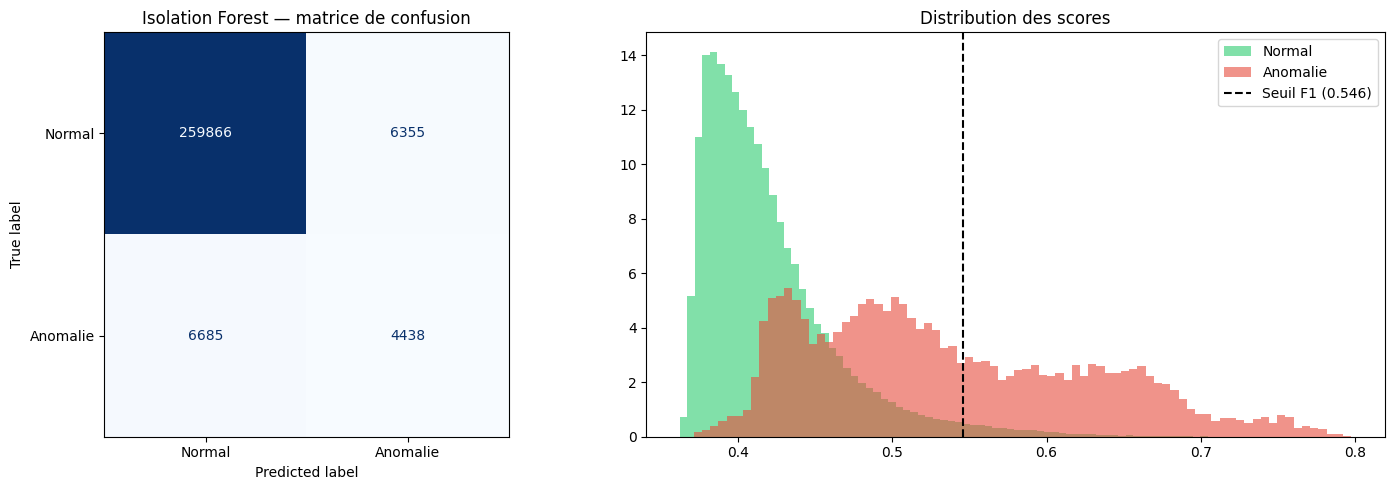

In [3]:
from sklearn.ensemble import IsolationForest
Xs=StandardScaler().fit_transform(df[FEAT].values)
contam=round(float(y_true.mean()),4)
model_if=IsolationForest(n_estimators=200, contamination=contam, random_state=42, n_jobs=-1).fit(Xs)
score_if=-model_if.score_samples(Xs)              # haut = plus anormal
auc_if=roc_auc_score(y_true, score_if)

# seuil par défaut (contamination)
yp_def=(model_if.predict(Xs)==-1).astype(int)
p0,r0,f0,_=precision_recall_fscore_support(y_true,yp_def,average='binary',zero_division=0)
# seuil optimisé pour le F1
thr_if,p1,r1,f1_if=best_f1_threshold(y_true, score_if)
y_pred_if=(score_if>=thr_if).astype(int)
print(f'AUC = {auc_if:.3f}')
print(f'  défaut (contamination) : P={p0:.3f} R={r0:.3f} F1={f0:.3f}')
print(f'  seuil F1-optimal       : P={p1:.3f} R={r1:.3f} F1={f1_if:.3f}')
results_detection.append({'model':'Isolation Forest','Précision':p1,'Rappel':r1,'F1':f1_if,'AUC':auc_if})

fig, axes=plt.subplots(1,2, figsize=(15,5))
ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred_if), display_labels=['Normal','Anomalie']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Isolation Forest — matrice de confusion')
axes[1].hist(score_if[y_true==0], bins=80, alpha=0.6, color=COLORS['normal'], label='Normal', density=True)
axes[1].hist(score_if[y_true==1], bins=80, alpha=0.6, color=COLORS['anomaly'], label='Anomalie', density=True)
axes[1].axvline(thr_if, color='black', ls='--', label=f'Seuil F1 ({thr_if:.3f})')
axes[1].set_title('Distribution des scores'); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig34_isolation_forest.png', bbox_inches='tight'); plt.show()

## 3. Modèle 2 — LSTM-Autoencoder (entraîné sur le NORMAL uniquement)
Séquences glissantes de 24 pas. L'AE n'apprend que des séquences **100 % normales** ; une grande
**erreur de reconstruction** = anomalie. Seuil choisi pour maximiser le F1.

Séquences totales : 277,056 | entraînement (normales) : 265,944
AUC = 0.600 | seuil F1-optimal : P=0.061 R=0.383 F1=0.105


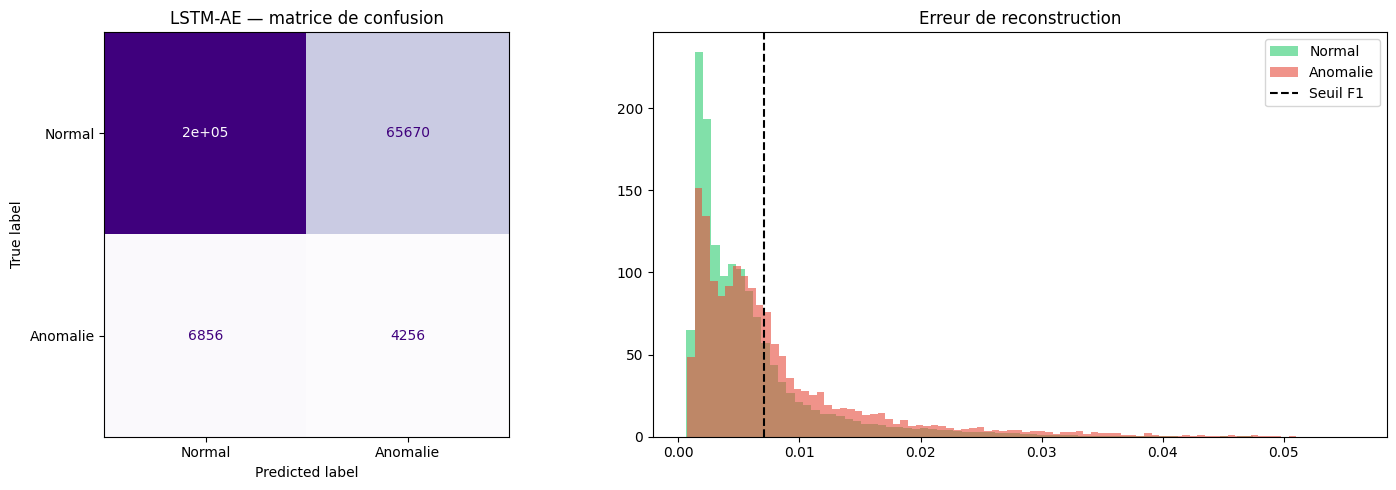

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

SEQ=24
# on construit les séquences PAR compteur (pas de chevauchement entre compteurs)
seqs, seq_label = [], []
scaler_ae=MinMaxScaler().fit(df[['consumptionliters']].values)
for mid, g in df.groupby('meterid'):
    vals=scaler_ae.transform(g[['consumptionliters']].values)
    lab =(g[LABEL_COL].values!='normal').astype(int)
    for i in range(SEQ, len(vals)):
        seqs.append(vals[i-SEQ:i,0])
        # une séquence est "anormale" si son dernier point l'est
        seq_label.append(lab[i])
X_seq=np.array(seqs).reshape(-1,SEQ,1); seq_label=np.array(seq_label)

# clé : entraînement sur séquences 100% normales seulement
# (ici : dernier point normal ; pour être strict on pourrait exiger toute la fenêtre normale)
train_mask = seq_label==0
X_ae_train = X_seq[train_mask]
print(f'Séquences totales : {len(X_seq):,} | entraînement (normales) : {len(X_ae_train):,}')

inp=Input(shape=(SEQ,1))
enc=LSTM(32, activation='tanh')(inp)
dec=RepeatVector(SEQ)(enc)
dec=LSTM(32, activation='tanh', return_sequences=True)(dec)
out=TimeDistributed(Dense(1))(dec)
ae=Model(inp,out); ae.compile(optimizer='adam', loss='mae')
ae.fit(X_ae_train, X_ae_train, epochs=15, batch_size=128, validation_split=0.1,
       callbacks=[EarlyStopping(patience=4, restore_best_weights=True)], verbose=0)

recon=ae.predict(X_seq, verbose=0)
err=np.mean(np.abs(recon-X_seq), axis=(1,2))
auc_ae=roc_auc_score(seq_label, err)
thr_ae,p_ae,r_ae,f_ae=best_f1_threshold(seq_label, err)
y_pred_ae=(err>=thr_ae).astype(int)
print(f'AUC = {auc_ae:.3f} | seuil F1-optimal : P={p_ae:.3f} R={r_ae:.3f} F1={f_ae:.3f}')
results_detection.append({'model':'LSTM-Autoencoder','Précision':p_ae,'Rappel':r_ae,'F1':f_ae,'AUC':auc_ae})

fig, axes=plt.subplots(1,2, figsize=(15,5))
ConfusionMatrixDisplay(confusion_matrix(seq_label,y_pred_ae), display_labels=['Normal','Anomalie']).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('LSTM-AE — matrice de confusion')
axes[1].hist(err[seq_label==0], bins=80, alpha=0.6, color=COLORS['normal'], label='Normal', density=True)
axes[1].hist(err[seq_label==1], bins=80, alpha=0.6, color=COLORS['anomaly'], label='Anomalie', density=True)
axes[1].axvline(thr_ae, color='black', ls='--', label='Seuil F1'); axes[1].set_title("Erreur de reconstruction"); axes[1].legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig35_lstm_ae.png', bbox_inches='tight'); plt.show()

## 4. Modèle 3 — Méthode statistique (3-sigma robuste sur résidus STL)

Seuils : [-235.8, 235.7] L | AUC=0.829 | P=0.220 R=0.628 F1=0.325


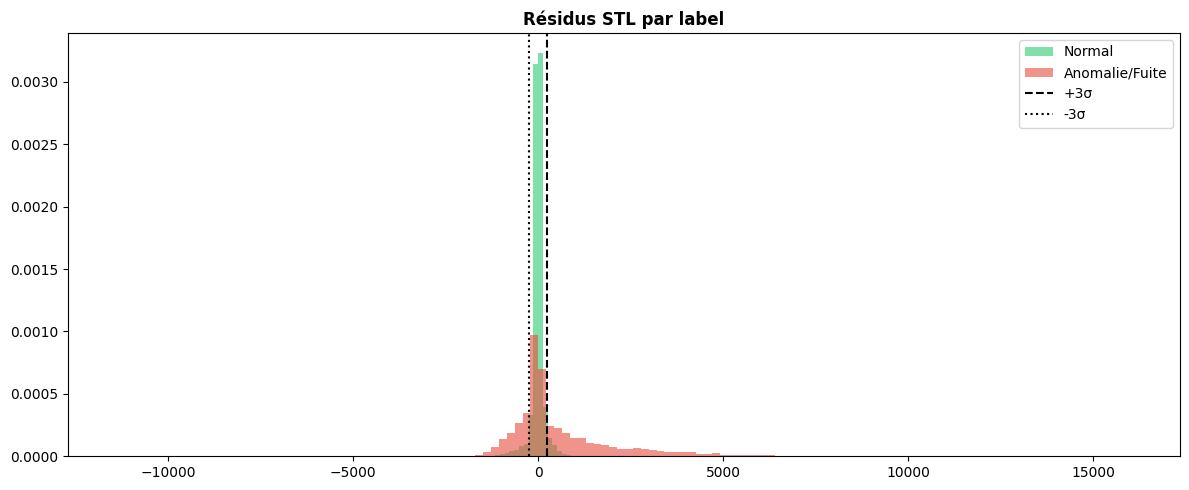

In [5]:
from statsmodels.tsa.seasonal import STL
residuals=np.full(len(df), np.nan)
for mid, g in df.groupby('meterid'):
    s=g['consumptionliters'].values
    if len(s) > 2*24:
        res=STL(s, period=24, robust=True).fit()
        residuals[g.index]=res.resid
mask=~np.isnan(residuals)
r=residuals[mask]; yt_s=y_true[mask]
med=np.median(r); mad=np.median(np.abs(r-med)); robust_std=1.4826*mad
hi=med+3*robust_std; lo=med-3*robust_std
y_pred_sigma=((r>hi)|(r<lo)).astype(int)
p_s,r_s,f_s,_=precision_recall_fscore_support(yt_s,y_pred_sigma,average='binary',zero_division=0)
score_sigma=np.abs(r-med)/(robust_std+1e-9)
auc_s=roc_auc_score(yt_s, score_sigma)
print(f'Seuils : [{lo:.1f}, {hi:.1f}] L | AUC={auc_s:.3f} | P={p_s:.3f} R={r_s:.3f} F1={f_s:.3f}')
results_detection.append({'model':'3-Sigma (STL)','Précision':p_s,'Rappel':r_s,'F1':f_s,'AUC':auc_s})

fig, ax=plt.subplots(figsize=(12,5))
ax.hist(r[yt_s==0], bins=100, alpha=0.6, color=COLORS['normal'], label='Normal', density=True)
ax.hist(r[yt_s==1], bins=100, alpha=0.6, color=COLORS['anomaly'], label='Anomalie/Fuite', density=True)
ax.axvline(hi, color='black', ls='--', label='+3σ'); ax.axvline(lo, color='black', ls=':', label='-3σ')
ax.set_title('Résidus STL par label', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig36_sigma3.png', bbox_inches='tight'); plt.show()

## 5. Comparaison des 3 modèles + courbes ROC

     COMPARAISON — DÉTECTION (seuils F1-optimaux)
                  Précision  Rappel     F1    AUC
model                                            
Isolation Forest      0.411   0.399  0.405  0.897
3-Sigma (STL)         0.220   0.628  0.325  0.829
LSTM-Autoencoder      0.061   0.383  0.105  0.600
🏆 Meilleur modèle (F1) : Isolation Forest


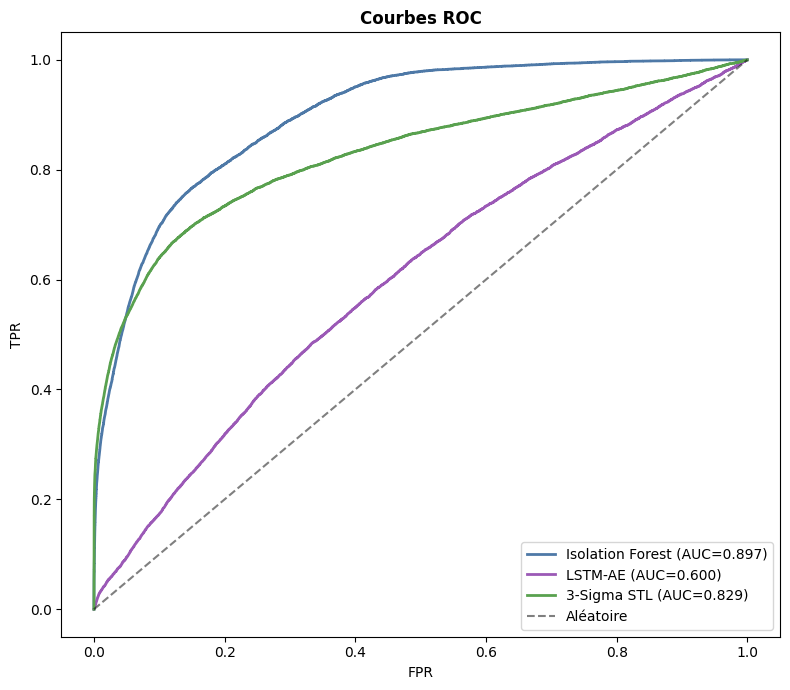

In [6]:
df_res=pd.DataFrame(results_detection).set_index('model').sort_values('F1', ascending=False)
print('='*60); print('     COMPARAISON — DÉTECTION (seuils F1-optimaux)'); print('='*60)
print(df_res.round(3).to_string()); print('='*60)
best_detector=df_res.index[0]; print(f'🏆 Meilleur modèle (F1) : {best_detector}')

fig, ax=plt.subplots(figsize=(8,7))
for (yt_, sc_, name, col) in [(y_true,score_if,'Isolation Forest',COLORS['if']),
                              (seq_label,err,'LSTM-AE',COLORS['lstm_ae']),
                              (yt_s,score_sigma,'3-Sigma STL',COLORS['sigma3'])]:
    fpr,tpr,_=roc_curve(yt_, sc_); ax.plot(fpr,tpr, lw=2, color=col, label=f'{name} (AUC={roc_auc_score(yt_,sc_):.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.5, label='Aléatoire')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Courbes ROC', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig(FIG_DIR/'fig39_roc.png', bbox_inches='tight'); plt.show()

In [7]:
# Analyse fuites vs anomalies pour le meilleur modèle (Isolation Forest si gagnant)
if best_detector=='Isolation Forest':
    yp_best=y_pred_if; labels_multi=df[LABEL_COL].values
    for lbl in ['anomaly','leak']:
        m=(labels_multi==lbl)|(labels_multi=='normal')
        yt_l=(labels_multi[m]==lbl).astype(int)
        from sklearn.metrics import f1_score, recall_score
        print(f'  {lbl:<8} : F1={f1_score(yt_l,yp_best[m],zero_division=0):.3f}  '
              f'Rappel={recall_score(yt_l,yp_best[m],zero_division=0):.3f}')

  anomaly  : F1=0.338  Rappel=0.389
  leak     : F1=0.283  Rappel=0.416


## 6. Sauvegarde des modèles

In [8]:
import joblib
joblib.dump(model_if, MODEL_DIR/'isolation_forest.pkl')
joblib.dump({'threshold':float(thr_if),'features':FEAT}, MODEL_DIR/'if_config.pkl')
ae.save(MODEL_DIR/'lstm_autoencoder.keras'); joblib.dump(scaler_ae, MODEL_DIR/'ae_scaler.pkl')
joblib.dump({'threshold':float(thr_ae),'seq_len':SEQ}, MODEL_DIR/'ae_config.pkl')
df_res.to_csv(MODEL_DIR/'detection_results.csv')

if best_detector=='Isolation Forest': joblib.dump(model_if, MODEL_DIR/'best_detector.pkl')
elif best_detector=='LSTM-Autoencoder': ae.save(MODEL_DIR/'best_detector.keras')
print(f'🏆 Meilleur détecteur sauvegardé : {best_detector}')
print('🏁 Notebook 03 terminé. Détection prête pour le backend.')

🏆 Meilleur détecteur sauvegardé : Isolation Forest
🏁 Notebook 03 terminé. Détection prête pour le backend.
